# Final Project MLOps: Model Training and Baseline Comparison (CP2)

Greycia Febrina Michelle & Aulia Aca Azzahra, SISTECH 2026

This notebook trains a model to predict Risk Score from the feature table built in CP1, `feature_table_fp.csv`. Before training anything, a baseline without machine learning is built first, so the model's value can be checked empirically rather than assumed.

One thing that makes this table different from Hands-On 2's data: every row here represents the same reference date, only the grid cell and hour vary. There is no calendar time axis to split on, so a chronological train and test split, the kind used in Hands-On 2, does not apply here. Instead, the split used below holds out entire grid cells the model has never seen, which matches how the API in CP2 will actually be used, a query can land on a location that was never part of the table the model was trained on.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
PRIMARY = "#A1007E"
ACCENT = "#D6008C"
TITLE_CLR = "#2A2882"
plt.rcParams["axes.titlecolor"] = TITLE_CLR

print("Setup complete")

Setup complete


## Loading the Feature Table

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/SISTECH/feature_table_fp.csv"
df = pd.read_csv(DATA_PATH)

FEATURE_COLS = ["lat_r", "lon_r", "hour_sin", "hour_cos", "nearby_crime_count"]
TARGET_COL = "risk_score"

print(f"Rows: {len(df):,}, unique cells: {df['cell_id'].nunique()}")
df.describe().round(2)

Rows: 17,424, unique cells: 726


,lat_r,lon_r,hour_sin,hour_cos,nearby_crime_count,risk_score
count,17424.00,17424.00,17424.00,17424.00,17424.00,17424.00
mean,41.84,-87.69,-0.00,-0.00,3745.86,77.67
std,0.11,0.09,0.71,0.71,3345.05,15.93
min,41.64,-87.93,-1.00,-1.00,9.00,8.18
25%,41.75,-87.74,-0.71,-0.71,1095.00,70.45
50%,41.84,-87.68,0.00,-0.00,3129.00,81.94
75%,41.94,-87.63,0.71,0.71,5579.00,88.87
max,42.02,-87.52,1.00,1.00,30360.00,100.00


## Splitting by Cell, Not by Row

A random row split would let the model see most cells during training, just at different hours, and only need to learn hour patterns within already familiar locations. Splitting by cell means an entire location, all 24 of its hours, goes to either train or test, never both. This is a harder and more honest test, matching what the live API will face when a query lands on a coordinate the model has no direct memory of.

In [4]:
unique_cells = df["cell_id"].unique()
rng = np.random.default_rng(42)
shuffled = rng.permutation(unique_cells)
split_point = int(len(shuffled) * 0.8)
train_cells = set(shuffled[:split_point])
test_cells = set(shuffled[split_point:])

train_df = df[df["cell_id"].isin(train_cells)].copy()
test_df = df[df["cell_id"].isin(test_cells)].copy()

print(f"Train cells: {len(train_cells)}, test cells: {len(test_cells)}")
print(f"Train rows: {len(train_df):,}, test rows: {len(test_df):,}")

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

Train cells: 580, test cells: 146
Train rows: 13,920, test rows: 3,504


## Baseline Without Machine Learning

Two simple baselines, neither one learns anything about location, one ignores everything and predicts the overall average, one only accounts for the hour of day.

In [5]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label:28s} MAE={mae:6.3f} RMSE={rmse:6.3f} R2={r2:6.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}


results = []

global_mean = y_train.mean()
results.append(evaluate(y_test, np.full(len(y_test), global_mean), "Baseline: global mean"))

hour_mean_map = train_df.groupby("hour_sin")[TARGET_COL].mean()
pred_hour = test_df["hour_sin"].map(hour_mean_map).fillna(global_mean)
results.append(evaluate(y_test, pred_hour, "Baseline: mean by hour"))

Baseline: global mean        MAE=12.255 RMSE=16.569 R2=-0.005
Baseline: mean by hour       MAE=12.211 RMSE=16.520 R2= 0.001


Both baselines come out close to useless, R2 near zero either way. That is expected here, hour alone barely moves the score, and ignoring location entirely throws away almost all the signal, since location is where most of the real variation lives.

## Checking for Non-Linearity Before Choosing a Model

The same check done in CP1 for the point query function, repeated here on the training table itself, to confirm the model choice is based on this table's actual shape, not just carried over by habit.

In [6]:
for q in [0, 0.25, 0.5, 0.75, 0.9, 0.99]:
    val = train_df["nearby_crime_count"].quantile(q)
    subset = train_df[train_df["nearby_crime_count"] <= val]
    print(f"nearby_crime_count <= {val:.0f} (percentile {q:.2f}): mean risk_score = {subset[TARGET_COL].mean():.2f}")

nearby_crime_count <= 9 (percentile 0.00): mean risk_score = 35.82
nearby_crime_count <= 1092 (percentile 0.25): mean risk_score = 56.36
nearby_crime_count <= 3168 (percentile 0.50): mean risk_score = 66.54
nearby_crime_count <= 5769 (percentile 0.75): mean risk_score = 73.04
nearby_crime_count <= 7977 (percentile 0.90): mean risk_score = 76.02
nearby_crime_count <= 16612 (percentile 0.99): mean risk_score = 77.73


The same clearly diminishing pattern as before. This justifies trying tree based models against the linear one, not just picking one out of habit.

## Training and Comparing Models

In [7]:
lin = LinearRegression().fit(X_train, y_train)
results.append(evaluate(y_test, lin.predict(X_test), "Linear Regression"))

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate(y_test, rf.predict(X_test), "Random Forest"))

gbr = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
results.append(evaluate(y_test, gbr.predict(X_test), "Gradient Boosting"))

results_df = pd.DataFrame(results).round(3)
results_df

Linear Regression            MAE= 8.037 RMSE=12.085 R2= 0.465
Random Forest                MAE= 3.980 RMSE= 5.846 R2= 0.875
Gradient Boosting            MAE= 3.639 RMSE= 5.145 R2= 0.903


,model,MAE,RMSE,R2
0,Baseline: global mean,12.255,16.569,-0.005
1,Baseline: mean by hour,12.211,16.520,0.001
2,Linear Regression,8.037,12.085,0.465
3,Random Forest,3.980,5.846,0.875
4,Gradient Boosting,3.639,5.145,0.903


Three metrics are tracked, each measuring something different. MAE is the primary one to read, since its unit matches the Risk Score scale directly, an MAE of 3.6 means predictions are off by about 3.6 points on average, in either direction. RMSE punishes large individual misses more than MAE does, since the errors are squared before averaging, so a big gap between RMSE and MAE would signal a few very wrong predictions dragging the average up, not a consistent small error across the board. Here they stay close together for the stronger models, meaning the errors are fairly even rather than a handful of outliers doing the damage. R2 answers a different question entirely, how much of the variation in Risk Score the model accounts for compared to just guessing the mean every time. An R2 near 0, like both baselines show, means the baseline is barely better than a flat guess. An R2 above 0.9 means the model is capturing almost all of the pattern in the data that can be captured with the features available.

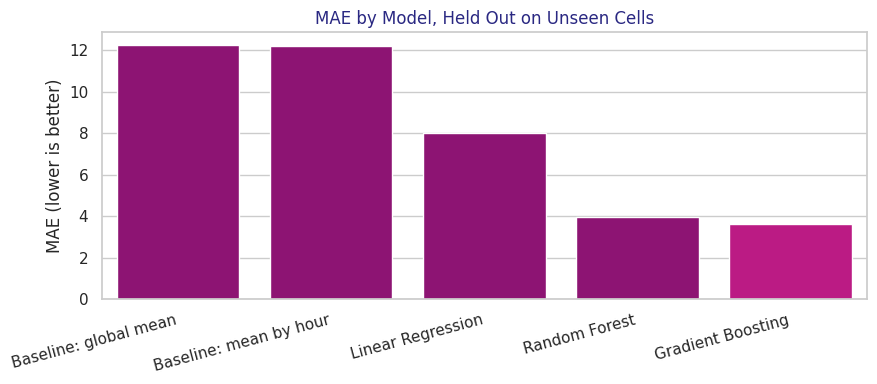

In [8]:
colors = [ACCENT if m == "Gradient Boosting" else PRIMARY for m in results_df["model"]]
plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="model", y="MAE", hue="model", palette=colors, legend=False)
plt.title("MAE by Model, Held Out on Unseen Cells")
plt.ylabel("MAE (lower is better)")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

This result looks different from Hands-On 2, where Linear Regression, Random Forest, and Gradient Boosting all landed within a fraction of a point of each other. Here, Gradient Boosting and Random Forest clearly pull ahead of Linear Regression. The difference comes from what the split is actually testing. Hands-On 2 evaluated on data that still overlapped heavily with training locations. Here, the model has to generalize to entire cells it has never seen, and a plain linear combination of latitude, longitude, and crime count cannot capture how risk clusters in specific neighborhoods the way a tree based model can.

`feature_importances_` on the Gradient Boosting model confirms which feature is doing almost all of the work.

In [9]:
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": gbr.feature_importances_,
}).sort_values("importance", ascending=False)
importance_df

,feature,importance
4,nearby_crime_count,0.960485
1,lon_r,0.017507
0,lat_r,0.014734
2,hour_sin,0.006210
3,hour_cos,0.001064


`nearby_crime_count` alone accounts for the overwhelming majority of the model's decisions, consistent with what CP1 already found about this feature dominating the label itself. Location and hour still matter, just far less by comparison.

## Checking the Split Is Not Just a Lucky Draw

One random split could look good or bad by chance. Both Random Forest and Gradient Boosting are retrained and re-evaluated across four different random seeds for the cell split, so the comparison between them is a fair rematch, not a conclusion drawn from the one split above.


In [10]:
seed_results = []

for seed in [1, 7, 42, 99]:
    rng_seed = np.random.default_rng(seed)
    shuffled_seed = rng_seed.permutation(unique_cells)
    split_seed = int(len(shuffled_seed) * 0.8)
    train_cells_seed = set(shuffled_seed[:split_seed])
    test_cells_seed = set(shuffled_seed[split_seed:])

    train_seed_df = df[df["cell_id"].isin(train_cells_seed)]
    test_seed_df = df[df["cell_id"].isin(test_cells_seed)]

    rf_seed = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    rf_seed.fit(train_seed_df[FEATURE_COLS], train_seed_df[TARGET_COL])
    pred_rf_seed = rf_seed.predict(test_seed_df[FEATURE_COLS])
    mae_rf_seed = mean_absolute_error(test_seed_df[TARGET_COL], pred_rf_seed)
    r2_rf_seed = r2_score(test_seed_df[TARGET_COL], pred_rf_seed)

    gbr_seed = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42)
    gbr_seed.fit(train_seed_df[FEATURE_COLS], train_seed_df[TARGET_COL])
    pred_gb_seed = gbr_seed.predict(test_seed_df[FEATURE_COLS])
    mae_gb_seed = mean_absolute_error(test_seed_df[TARGET_COL], pred_gb_seed)
    r2_gb_seed = r2_score(test_seed_df[TARGET_COL], pred_gb_seed)

    seed_results.append({"seed": seed, "rf_mae": mae_rf_seed, "rf_r2": r2_rf_seed,
                          "gb_mae": mae_gb_seed, "gb_r2": r2_gb_seed})
    print(f"seed={seed}: RF MAE={mae_rf_seed:.3f} R2={r2_rf_seed:.3f} | "
          f"GB MAE={mae_gb_seed:.3f} R2={r2_gb_seed:.3f}")

seed_results_df = pd.DataFrame(seed_results)
gb_wins = (seed_results_df["gb_mae"] < seed_results_df["rf_mae"]).sum()
print(f"\nGradient Boosting has the lower MAE in {gb_wins} out of {len(seed_results_df)} seeds")
print(f"RF mean MAE across seeds: {seed_results_df['rf_mae'].mean():.3f}")
print(f"GB mean MAE across seeds: {seed_results_df['gb_mae'].mean():.3f}")


seed=1: RF MAE=3.378 R2=0.916 | GB MAE=3.015 R2=0.936
seed=7: RF MAE=3.811 R2=0.894 | GB MAE=3.601 R2=0.911
seed=42: RF MAE=3.980 R2=0.875 | GB MAE=3.639 R2=0.903
seed=99: RF MAE=4.043 R2=0.899 | GB MAE=3.678 R2=0.916

Gradient Boosting has the lower MAE in 4 out of 4 seeds
RF mean MAE across seeds: 3.803
GB mean MAE across seeds: 3.483


Gradient Boosting has the lower MAE in every one of the four seeds, not just the one used for the main comparison earlier. The gap holds at roughly half a point of MAE in each case, not a margin that flips with a different split.

This is the fair rematch the single-split comparison above could not settle on its own. Random Forest is a solid model on this data, R2 stays above 0.87 in every seed, but Gradient Boosting is ahead consistently, not by luck of one draw.

Gradient Boosting is the model taken forward.


## Training the Deployed Model on the Full Table

The evaluation above intentionally held out 20 percent of cells to measure honest performance. The model actually shipped for the API is trained on the complete table instead, no held out data, since there is no reason to withhold real signal from the version that will actually answer live queries. The held out evaluation above is what gets reported as this model's expected accuracy, not a claim about the final deployed model specifically.

In [11]:
final_model = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42)
final_model.fit(df[FEATURE_COLS], df[TARGET_COL])

print("Final model trained on", len(df), "rows")

Final model trained on 17424 rows


In [12]:
import joblib
import json
from datetime import datetime, timezone

joblib.dump(final_model, "/content/drive/MyDrive/SISTECH/model_v0.joblib")

registry_entry = {
    "version": 0,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "training_rows": len(df),
    "feature_cols": FEATURE_COLS,
    "algorithm": "GradientBoostingRegressor",
    "hyperparameters": {"n_estimators": 150, "max_depth": 3, "random_state": 42},
    "holdout_metrics": {
        "MAE": float(results_df.loc[results_df["model"] == "Gradient Boosting", "MAE"].iloc[0]),
        "RMSE": float(results_df.loc[results_df["model"] == "Gradient Boosting", "RMSE"].iloc[0]),
        "R2": float(results_df.loc[results_df["model"] == "Gradient Boosting", "R2"].iloc[0]),
    },
    "decision": "initial_model",
    "reason": "First trained model for CP2, evaluated on a cell based holdout split before being retrained on the full table for deployment.",
    "checkpoint_path": "models/model_v0.joblib",
}

with open("/content/drive/MyDrive/SISTECH/registry.json", "w") as f:
    json.dump([registry_entry], f, indent=2)

print("Model and registry saved")

Model and registry saved


`model_v0.joblib` and `registry.json` above are this notebook's own training log. The API loads a different pair, `champion.joblib` and `champion_meta.json`, read through `src/registry.py` on the API side, so both are saved here from the same fitted model, using the same plain `joblib.dump` and `json.dump` pattern as the cell above rather than importing a module this notebook has no direct access to.


In [13]:
joblib.dump(final_model, "/content/drive/MyDrive/SISTECH/champion.joblib")

champion_meta = {
    "version": 0,
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET_COL,
    "metrics_holdout": registry_entry["holdout_metrics"],
    "updated_at": datetime.now(timezone.utc).isoformat(),
}

with open("/content/drive/MyDrive/SISTECH/champion_meta.json", "w") as f:
    json.dump(champion_meta, f, indent=2)

print("champion.joblib and champion_meta.json saved, this is what api/main.py actually loads")


champion.joblib and champion_meta.json saved, this is what api/main.py actually loads


## A Limitation Found While Testing the API

While testing the API built around this model, one case exposed a real gap. A location far outside Chicago, with `nearby_crime_count` equal to 0, was fed into the model directly, and it returned a risk score around 29, not the 0 the final project's example table asks for.

The reason is that this model never saw `nearby_crime_count` below 9 during training, the training table only contains cells that had at least some history. Tree based models like Gradient Boosting do not extrapolate the way a formula would, a value below anything seen in training just gets mapped to the nearest leaf the model does remember, not to zero.

The fix lives in the API itself, not in the model. Before calling the model, the API checks `nearby_crime_count` directly, if it is exactly 0, the response returns a risk score of 0 immediately and skips the model entirely. This keeps the guarantee from CP1's formula based scoring (no history nearby means zero risk) intact, even though the model driving everything else cannot make that guarantee on its own.